# **Atlántico**

El Atlántico es uno de los 32 departamentos que conforman la república de Colombia. Se encuentra conformado por 22 Municipios y el Distrito Especial Industrial y Portuario de Barranquilla, su capital.

Está situado al norte del territorio nacional, límita por el norte y noreste con el mar Caribe, en una extensión aproximada de 90 Km; desde el rompeolas occidental en Bocas de Ceniza, hasta las salinas de Galerazamba. Al este, con el río Magdalena, en una longitud de 105 Km, contados desde su desembocadura en Bocas de Ceniza hasta el desprendimiento del Canal del Dique en Calamar; al sur, suroeste y oeste con el departamento de Bolívar desde Calamar hasta las Salinas de Galerazamba.

Presenta un clima tropical de tipo estepa y sabana de carácter árido en la desembocadura del río Magdalena y alrededores de Barranquilla; semi-árido en las fajas aledañas al litoral y al río Magdalena y semihúmedo desde Sabanalarga hacia el sur.

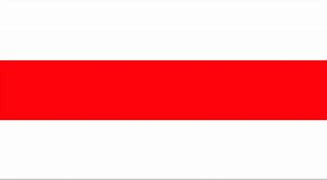

> Para el análisis se cuenta con 18,576 registros correspondientes a casos ocurridos en alguno de los 22 municipios del departamento del atlántico, representado en 21 variables, en el periodo del año 2017 al año 2023.


_____________

In [65]:
# [Configuración] Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from scipy import stats
import matplotlib.cm as cm

In [18]:
# [Configuración] Leer data
df = pd.read_csv(r"C:\Users\Hp\DENGUE\DATA\Data_Atlantico.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18576 entries, 0 to 18575
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   sexo                   18576 non-null  object
 1   edad_años              18576 non-null  int64 
 2   ciclo_vital            18576 non-null  object
 3   grupo_etnico           18576 non-null  object
 4   regimen_salud          18576 non-null  object
 5   evento                 18576 non-null  object
 6   tipo_de_caso           18576 non-null  object
 7   hospitalizacion        18576 non-null  object
 8   desenlace              18576 non-null  object
 9   año                    18576 non-null  int64 
 10  semana                 18576 non-null  int64 
 11  periodo                18576 non-null  int64 
 12  fecha_inicio_sintomas  18576 non-null  object
 13  fecha_consulta         18576 non-null  object
 14  fecha_hospitalizacion  18576 non-null  object
 15  fecha_notificacion 

In [19]:
# [] Convertir fechas a DateTime
columnas_fecha = ["fecha_consulta", "fecha_inicio_sintomas", "fecha_notificacion", "fecha_nacimiento", "fecha_hospitalizacion"]

for col in columnas_fecha:
    df[col] = df[col].replace(["--", "  -   -", "-", " "], pd.NA)
    df[col] = pd.to_datetime(df[col], format='mixed')
    print(f"Columna '{col}' convertida a datetime.")

Columna 'fecha_consulta' convertida a datetime.
Columna 'fecha_inicio_sintomas' convertida a datetime.
Columna 'fecha_notificacion' convertida a datetime.
Columna 'fecha_nacimiento' convertida a datetime.
Columna 'fecha_hospitalizacion' convertida a datetime.


In [20]:
# [] Valores nulos por variable
faltantes = df.isnull().sum()
print("Valores faltantes por variable: \n")
print(faltantes[faltantes > 0])

Valores faltantes por variable: 

fecha_hospitalizacion    7706
fecha_nacimiento          525
localidad                3218
barrio                    244
direccion                   1
dtype: int64


## **1. Descriptivo de variables**

In [21]:
# [Función] Descripción de variables categóricas

def describir_categorica(columna, col_evento="evento"):
    tabla = pd.DataFrame({
        "Conteo": columna.value_counts(dropna=False),
        "Proporción": columna.value_counts(normalize=True, dropna=False).round(4)
    })

    tabla.index = tabla.index.map(lambda x: "NaN" if pd.isna(x) else x)
    crosstab_evento = pd.crosstab(df[columna.name], df[col_evento])
    tabla_completa = tabla.join(crosstab_evento)

    # Agregar proporciones específicas para 'Clasico' y 'Grave'
    if "Clasico" in crosstab_evento.columns:
        tabla_completa["Prop_Clasico"] = (tabla_completa["Clasico"] / tabla_completa["Conteo"]).round(4)
    else:
        tabla_completa["Prop_Clasico"] = 0
    if "Grave" in crosstab_evento.columns:
        tabla_completa["Prop_Grave"] = (tabla_completa["Grave"] / tabla_completa["Conteo"]).round(4)
    else:
        tabla_completa["Prop_Grave"] = 0

    print(f"\n📌 Variable: {columna.name}")
    print(tabla_completa)
    print("\n-----------------------------------")



### 2.1 Variables demográficas

In [22]:
print("DESCRIPCIÓN DE VARIABLES CATEGÓRICAS")
describir_categorica(df["ciclo_vital"])
describir_categorica(df["sexo"])
describir_categorica(df["grupo_etnico"])
describir_categorica(df["regimen_salud"])


DESCRIPCIÓN DE VARIABLES CATEGÓRICAS

📌 Variable: ciclo_vital
                  Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
ciclo_vital                                                                   
Adolescencia        7849      0.4225     7662    187        0.9762      0.0238
Adulto              4096      0.2205     3987    109        0.9734      0.0266
Infancia            4066      0.2189     3991     75        0.9816      0.0184
Primera infancia    1925      0.1036     1901     24        0.9875      0.0125
Adulto mayor         482      0.0259      462     20        0.9585      0.0415
Menor de 1 año       113      0.0061      112      1        0.9912      0.0088
Ancianidad            45      0.0024       43      2        0.9556      0.0444

-----------------------------------

📌 Variable: sexo
           Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
sexo                                                                   
Masculino    9741      0.524

La población infectada por dengue en el Atlántico está en su mayoría, en edad adolescente (42.2%), seguida de población adulta (22.1%) e infantes (21.8%); estos grupos etarios son los de mayor exposición al estar en el medio educativo y laboral. Se resalta que para la población adulto mayor y ancianidad, se presentan una proporción más elevada de dengue grave, lo que manifiesta una mayor vulnerabilidad clínica en estas etapas. 

La distribución de casos por sexo es equilibrada, siento el 52.4% masculinos. En términos étnicos, solo un 2.17% de casos se asocia a pacientes pertenecientes a un grupo étnico. Los pacientes, en su mayoría están afiliados al régimen de salud subsidiado (53.5%) y contributivo (39.1%), no obstante, aunque la población de pacientes no asegurados representan apenas el 2.3% de los casos, concentran una mayor proporción de dengue grave (6.3%), lo que sugiere una posible asociación entre la ausencia de cobertura en salud y un peor desenlace clínico del dengue. 

In [23]:
# [Análisis] Edad de los pacientes
df_edad = df[df["ciclo_vital"] != "Menor de 1 año"].copy()

# Definir orden cronológico SIN "Menor de 1 año"
orden_ciclos_edad = [
    "Primera infancia",
    "Infancia",
    "Adolescencia",
    "Adulto",
    "Adulto mayor",
    "Ancianidad"
]

df_edad["ciclo_vital"] = pd.Categorical(
    df_edad["ciclo_vital"], 
    categories=orden_ciclos_edad, 
    ordered=True
)

def tabla_descriptiva(df, variable, grupo=None):
    """
    Genera una tabla descriptiva (media, mediana, DE, IQR, etc.)
    por grupos (ej. ciclo vital).
    """
    if grupo:
        desc = df.groupby(grupo)[variable].agg(
            n = 'count',
            media = 'mean',
            mediana = 'median',
            sd = 'std',
            q25 = lambda x: np.percentile(x, 25),
            q75 = lambda x: np.percentile(x, 75),
            minimo = 'min',
            maximo = 'max'
        ).reset_index()
    else:
        desc = df[variable].agg(
            n = 'count',
            media = 'mean',
            mediana = 'median',
            sd = 'std',
            q25 = lambda x: np.percentile(x, 25),
            q75 = lambda x: np.percentile(x, 75),
            minimo = 'min',
            maximo = 'max'
        ).to_frame().T
    return desc.round(2)

tabla = tabla_descriptiva(df_edad, variable="edad_años", grupo="ciclo_vital")
tabla

C:\Users\Hp\AppData\Local\Temp\ipykernel_28248\642813935.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  desc = df.groupby(grupo)[variable].agg(


,ciclo_vital,n,media,mediana,sd,q25,q75,minimo,maximo
0,Primera infancia,1925,2.56,3.0,1.17,1.0,4.0,1,4
1,Infancia,4066,7.20,7.0,1.38,6.0,8.0,5,9
2,Adolescencia,7849,13.91,14.0,2.69,12.0,16.0,10,19
3,Adulto,4096,30.70,27.0,10.30,22.0,36.0,20,59
4,Adulto mayor,482,69.12,68.0,6.91,63.0,74.0,60,84
5,Ancianidad,45,89.38,88.0,3.89,86.0,91.0,85,101


La edad de los pacientes, diferenciada entre grupos etarios, se distribuye de la siguiente manera: 

* Primera infancia [1-4 años]: Mayor concentración de edades al rededor de los 3 años.
* Infancia [5-9 años]: Edad concentrada entre los 6-8 años.
* Adolescencia [10-19 años]: Mayor cantidad de pacientes entre los 12-16 años.
* Adulto [20-59 años]: Mayoría de pacientes entre los 22-36 años.
* Adulto mayor [60 - 84 años]: Edades entre los 63-74 años.
* Ancianidad [85 -101 años]: Concentración de edades entre los 86-91 años. 

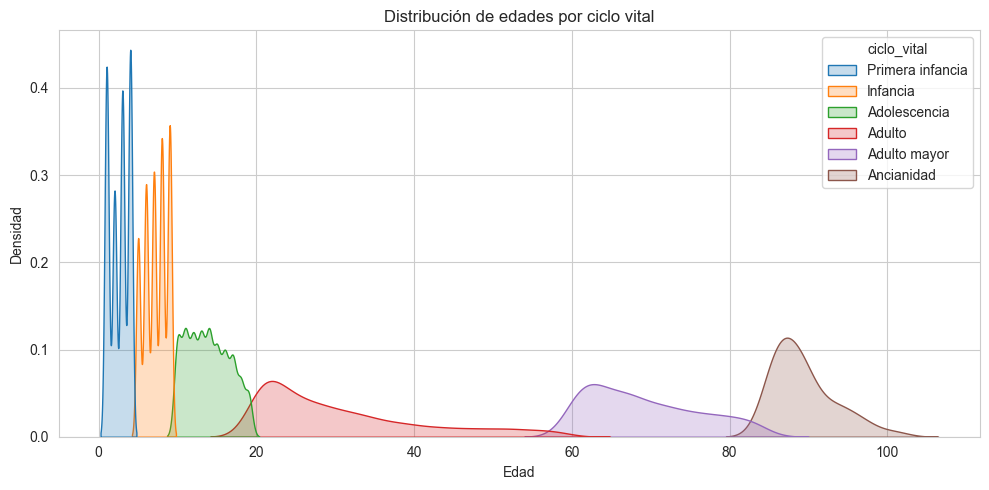

C:\Users\Hp\AppData\Local\Temp\ipykernel_28248\1052704811.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=grupo, y=variable, palette="Blues")


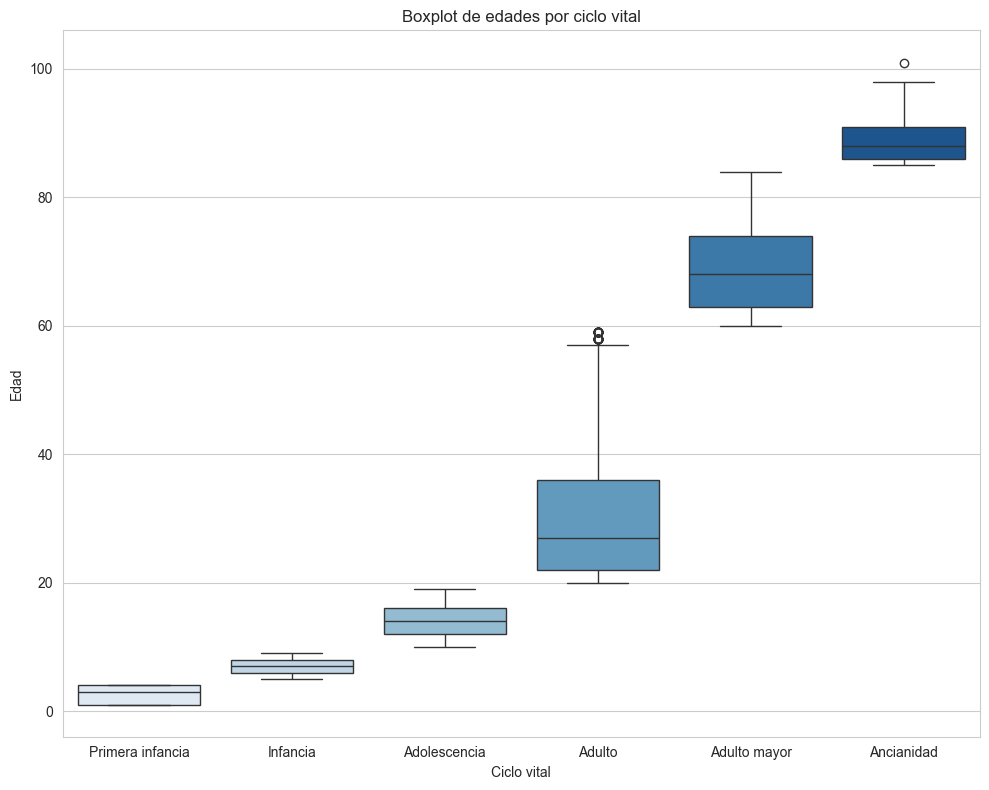

In [68]:
def graficos(df, variable, grupo):
    """
    Genera:
    1. Histograma + densidad global
    2. Densidad por ciclo vital
    3. Boxplot por ciclo vital
    """

    # --- 2. Densidad por ciclo vital ---
    plt.figure(figsize=(10,5))
    sns.kdeplot(data=df, x=variable, hue=grupo, common_norm=False, fill=True)
    plt.title("Distribución de edades por ciclo vital")
    plt.xlabel("Edad")
    plt.ylabel("Densidad")
    plt.tight_layout()
    plt.show()

    # --- 3. Boxplot por ciclo vital ---
    plt.figure(figsize=(10,8))
    sns.boxplot(data=df, x=grupo, y=variable, palette="Blues")
    plt.title("Boxplot de edades por ciclo vital")
    plt.xlabel("Ciclo vital")
    plt.ylabel("Edad")
    plt.tight_layout()
    plt.show()

graficos(df_edad, variable="edad_años", grupo="ciclo_vital")

Los gráficos representan la distribución de la edad, discriminada por grupos etarios, donde se evidencia que para las primeras etapas de la vida, la distribución de la edad de los pacientes es homogénea. La etapa adulta es la de mayor variabilidad, con sesgo positivo, lo que indica una mayor proporción de casos hacia los adultos mas jóvenes. Misma dinámica se aprecia para el grupo Adulto mayor y Ancianidad.

### 2.2 Variables de evento



In [25]:
describir_categorica(df['evento'])
describir_categorica(df['tipo_de_caso'])
describir_categorica(df['hospitalizacion'])
describir_categorica(df['desenlace'])


📌 Variable: evento
         Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
evento                                                               
Clasico   18158      0.9775    18158      0           1.0         0.0
Grave       418      0.0225        0    418           0.0         1.0

-----------------------------------

📌 Variable: tipo_de_caso
                       Conteo  Proporción  Clasico  Grave  Prop_Clasico  \
tipo_de_caso                                                              
Probable                13611      0.7327    13311    300         0.978   
Conf. por laboratorio    4912      0.2644     4794    118         0.976   
Conf. por nexo             53      0.0029       53      0         1.000   

                       Prop_Grave  
tipo_de_caso                       
Probable                    0.022  
Conf. por laboratorio       0.024  
Conf. por nexo              0.000  

-----------------------------------

📌 Variable: hospitalizacion
               

El dengue clásico en el Atlántico tiene una representatividad del 97.8% de casos (181,158) frente al 2.3% de casos graves (418) en todo el territorio. En su mayoría los registros analizados corresponden a casos probables (73.3%), solo el 26.4% fueron casos confirmados por prueba en laboratorio. Todos los casos confirmados por nexo epidemiológico (53) se relacionan al dengue clásico. 

De los casos registrados, se tiene que solo el 58.5% de los pacientes requirieron hospitalización, mientras que el 41.5% fueron manejados de manera ambulatoria. De los 418 casos de dengue grave, 10 no fueron hospitalizados. 

En relación a los fallecidos, la mortalidad registrada es mínima, existiendo solo 7 pacientes fallecidos, todos por dengue grave.

### 2.3 Variables espaciales

In [26]:
describir_categorica(df["area"])
describir_categorica(df['municipio'])


📌 Variable: area
                    Conteo  Proporción  Clasico  Grave  Prop_Clasico  \
area                                                                   
Cabecera municipal   17839      0.9603    17437    402        0.9775   
Centro Poblado         644      0.0347      630     14        0.9783   
Rural disperso          93      0.0050       91      2        0.9785   

                    Prop_Grave  
area                            
Cabecera municipal      0.0225  
Centro Poblado          0.0217  
Rural disperso          0.0215  

-----------------------------------

📌 Variable: municipio
                  Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
municipio                                                                     
SOLEDAD             8790      0.4732     8623    167        0.9810      0.0190
MALAMBO             2087      0.1123     2045     42        0.9799      0.0201
BARANOA             1206      0.0649     1186     20        0.9834      0.0166
S

Los casos de dengue se registraron en su mayoría en una cabecera municipal (96%), siendo solo el 4% en un centro poblado o rural disperso. 

La dinámica por municipios es variada, en datos netos, los municipios metropolitanos de Soledad y Malambo registran la mayor cantidad de casos de dengue clásico y grave. La mitad de los casos se concentra en el municipio de Soledad (47.3%) con 8,623 casos, de los cuales 167 son de dengue grave. 

Luego, los municipios de Baranoa, Sabanalarga y Galapa, constituyen un bloque de más de 1,000 casos reportados, representando cada uno un 6% del total de casos, conformando el núcleo de mayor transmisión. Cabe resaltar que en el municipio de Puerto Colombia, se registro la mayor cantidad de casos graves (57) después de Soledad. 

Con menor representatividad, sin superar los 100 registros, se encuentran los municipios de Candelaria, Piojó y Santa Lucía, este último, no presenta casos por dengue grave. 

En resumen, la epidemia de dengue en el departamento del Atlántico presenta un patrón predominante urbano, con concentración en los municipios del área metropolitana y céntrica, lo cual podría reflejar tanto características locales de transmisión como posibles diferencias en el acceso a diagnóstico oportuno.

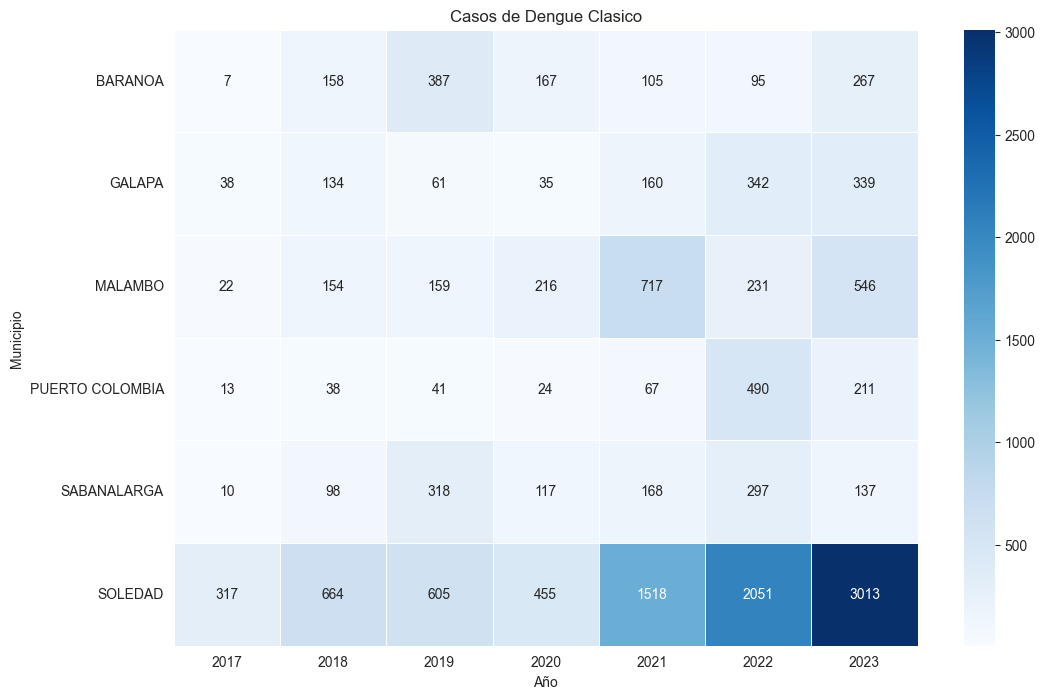

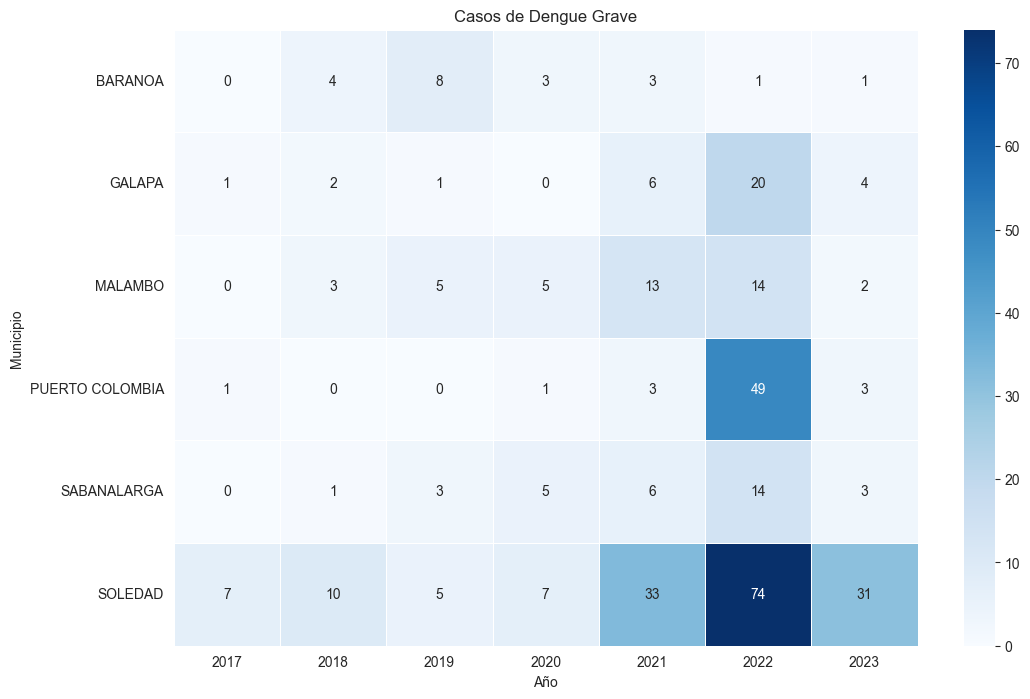

In [67]:
# 
tabla_mun = df.groupby(["municipio", "año", "evento"]).size().reset_index(name="casos")
totales_mun = tabla_mun.groupby("municipio")["casos"].sum()

municipios_filtrados = totales_mun[totales_mun > 800].index
tabla_filtrada = tabla_mun[tabla_mun["municipio"].isin(municipios_filtrados)]

eventos = ["Clasico", "Grave"]

for evento in eventos:
    tabla_evento = tabla_filtrada[tabla_filtrada["evento"] == evento]

    # Crear tabla pivote
    pivot = tabla_evento.pivot_table(
        index="municipio", 
        columns="año", 
        values="casos", 
        fill_value=0
    ).astype(int)

    # Graficar
    plt.figure(figsize=(12,8))
    sns.heatmap(pivot, cmap="Blues", linewidths=0.5, annot=True, fmt="d")
    plt.title(f"Casos de Dengue {evento}")
    plt.xlabel("Año")
    plt.ylabel("Municipio")
    plt.show()


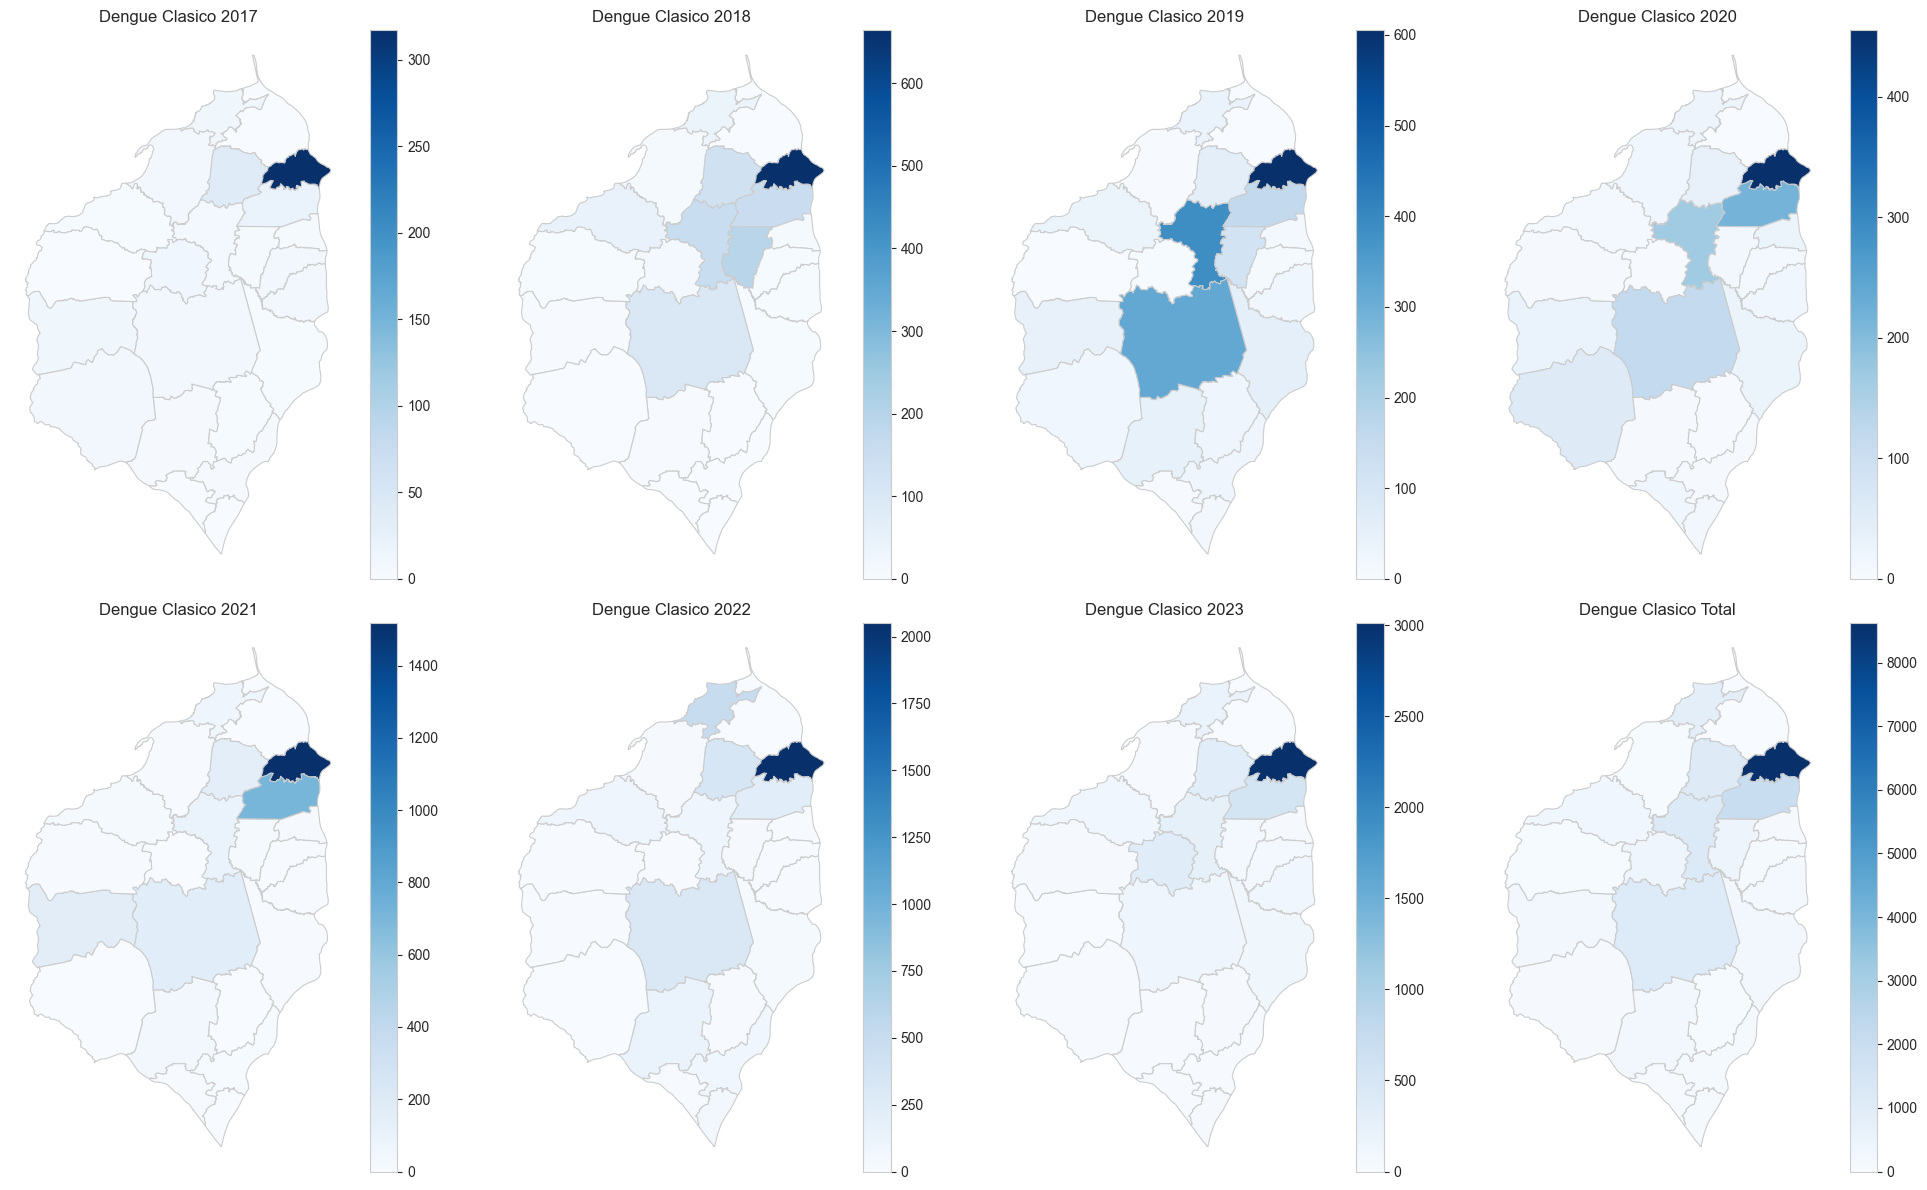

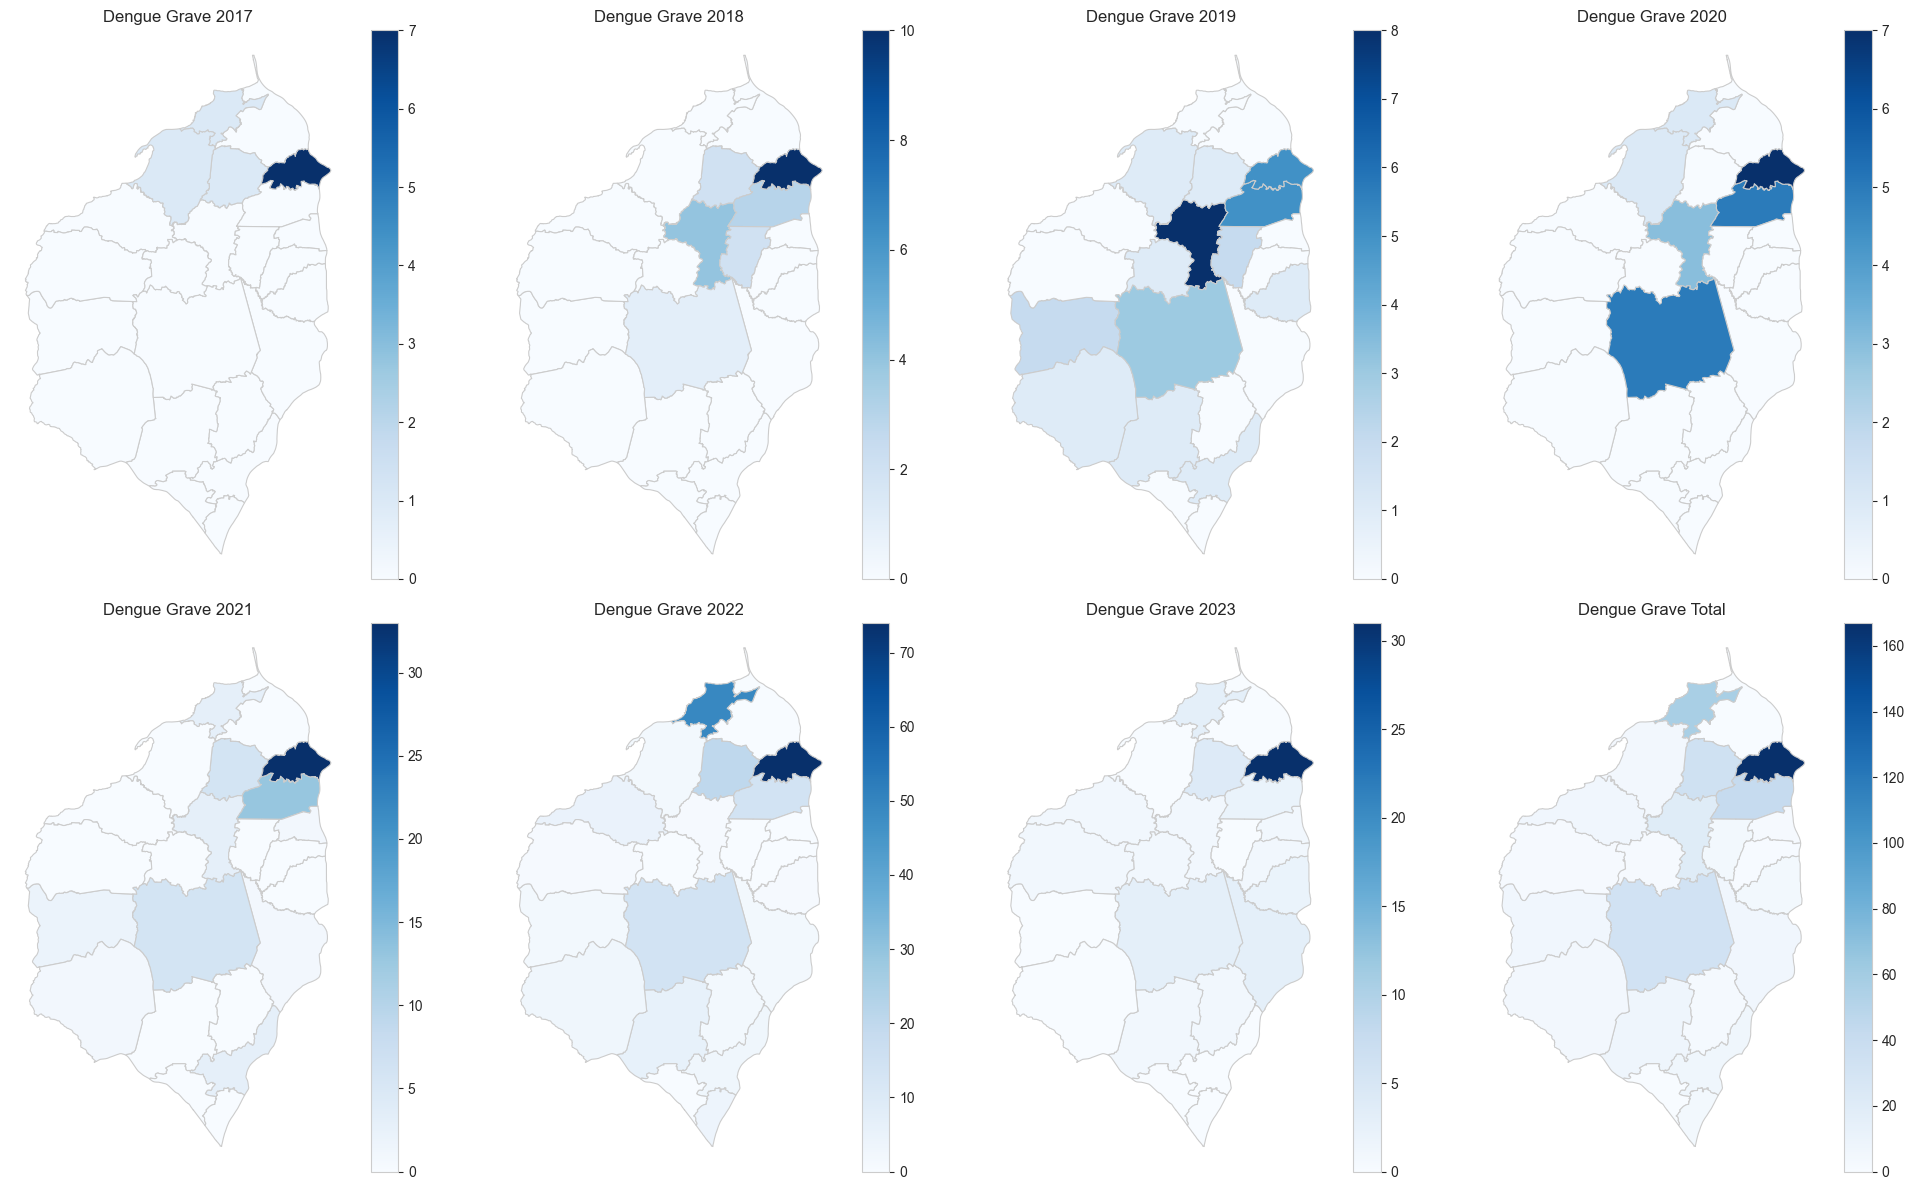

In [61]:
# Leer shapefile
gdf = gpd.read_file("Mapas/Municipio/MGN_ADM_MPIO_GRAFICO.shp", encoding='utf_8')
gdf = gdf.rename(columns={'mpio_cnmbr': 'municipio'}) 
gdf = gdf[gdf['dpto_cnmbr'] == 'ATLÁNTICO']

# Lista de eventos
eventos = ["Clasico", "Grave"]

for evento in eventos:
    anios = sorted(df["año"].unique())
    n = len(anios) + 1  # años + total

    # Calcular número de filas y columnas dinámicamente
    columnas = 4
    filas = (n + columnas - 1) // columnas

    fig, axes = plt.subplots(filas, columnas, figsize=(5*columnas, 6*filas))
    axes = axes.flatten()

    # Mapas por año
    for i, anio in enumerate(anios):
        casos_anio = (
            df[(df["año"] == anio) & (df["evento"] == evento)]
            .groupby("municipio")
            .size()
            .reset_index(name="CASOS")
        )

        gdf_plot = gdf.merge(casos_anio, on="municipio", how="left").fillna(0)

        gdf_plot.plot(column="CASOS", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                      legend=True, ax=axes[i])
        axes[i].set_title(f"Dengue {evento} {anio}")
        axes[i].axis("off")

    # Mapa total por evento
    casos_total = (
        df[df["evento"] == evento]
        .groupby("municipio")
        .size()
        .reset_index(name="CASOS")
    )

    gdf_total = gdf.merge(casos_total, on="municipio", how="left").fillna(0)

    gdf_total.plot(column="CASOS", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                   legend=True, ax=axes[-1])
    axes[-1].set_title(f"Dengue {evento} Total")
    axes[-1].axis("off")

    # Ocultar subplots vacíos (si sobran)
    for j in range(len(anios) + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


### 2.3 Variables temporales

In [28]:
describir_categorica(df["año"])


📌 Variable: año
      Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
año                                                               
2023    5665      0.3050     5609     56        0.9901      0.0099
2022    4257      0.2292     4054    203        0.9523      0.0477
2021    3171      0.1707     3099     72        0.9773      0.0227
2019    2063      0.1111     2031     32        0.9845      0.0155
2018    1613      0.0868     1591     22        0.9864      0.0136
2020    1295      0.0697     1273     22        0.9830      0.0170
2017     512      0.0276      501     11        0.9785      0.0215

-----------------------------------


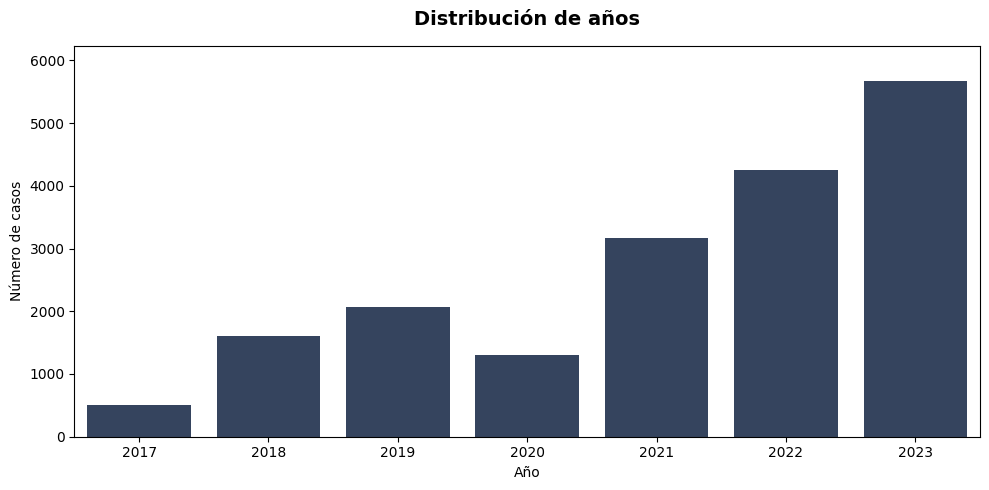

In [29]:
conteo_por_año = df['año'].value_counts(sort=False).sort_index()

    # Crear gráfico
plt.figure(figsize=(10, 5))
sns.barplot(x=conteo_por_año.index.astype(str), y=conteo_por_año.values, color='#2E4265')

plt.title('Distribución de años', fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Año")
plt.ylabel("Número de casos")
plt.xticks(rotation=0)
plt.ylim(0, max(conteo_por_año.values) * 1.1)
plt.tight_layout()
plt.show()


La variabilidad de los casos en el tiempo, muestra una notoria tendencia hacía la alza al pasar de los años, con variaciones importantes. Del 2017 al 2019, se obtienen la menor cantidad de registros, solo el 27% de los casos se dieron en este tiempo. En este periodo se evidencia un ciclo de crecimiento con caída hacia el 2020, para seguir la tendencia de crecimiento hacia el 2023. El año 2022, es el que mayor registro de casos de dengue grave presenta, unos 203 pacientes. 

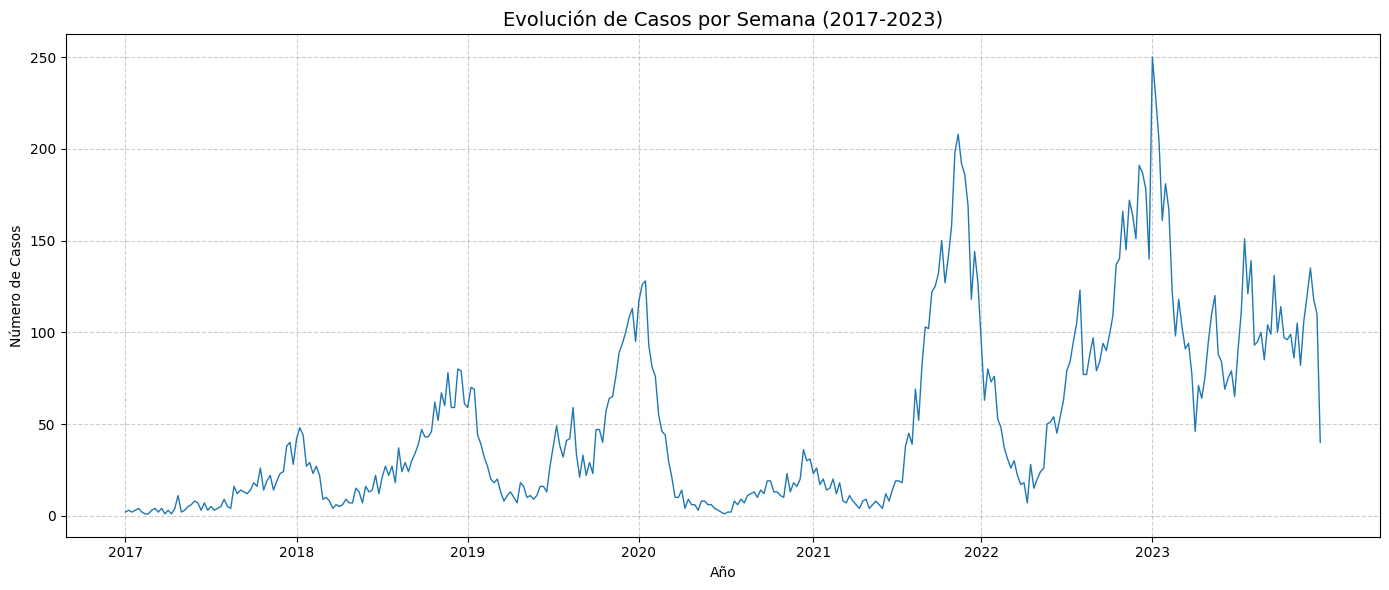

In [33]:
# [] Casos por semana
casos_semana = df.groupby(["año", "semana"]).size().reset_index(name="casos")
casos_semana = casos_semana.sort_values(["año", "semana"]).reset_index(drop=True)
casos_semana["index"] = range(len(casos_semana))

# Graficar
plt.figure(figsize=(14, 6))
plt.plot(casos_semana["index"], casos_semana["casos"], linewidth=1)
años_unicos = casos_semana["año"].unique()
ticks = [casos_semana[casos_semana["año"] == año].index[0] for año in años_unicos]
plt.xticks(ticks, años_unicos, fontsize=10)
plt.title("Evolución de Casos por Semana (2017-2023)", fontsize=14)
plt.xlabel("Año")
plt.ylabel("Número de Casos")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [34]:
week = tabla_descriptiva(df_edad, variable="semana", grupo="año")
week

,año,n,media,mediana,sd,q25,q75,minimo,maximo
0,2017,505,38.36,42.0,12.61,33.0,49.0,1,52
1,2018,1604,33.51,39.0,16.24,24.0,47.0,1,52
2,2019,2050,32.72,38.0,16.97,21.0,47.0,1,52
3,2020,1287,17.04,7.0,18.23,3.0,35.0,1,53
4,2021,3157,39.97,43.0,11.15,37.0,47.0,1,52
5,2022,4245,33.81,38.0,15.08,26.0,46.0,1,52
6,2023,5615,24.39,25.0,16.10,8.0,38.0,1,52


C:\Users\Hp\AppData\Local\Temp\ipykernel_28248\1452467844.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = cm.get_cmap('Blues', len(años))  # paleta con N tonos


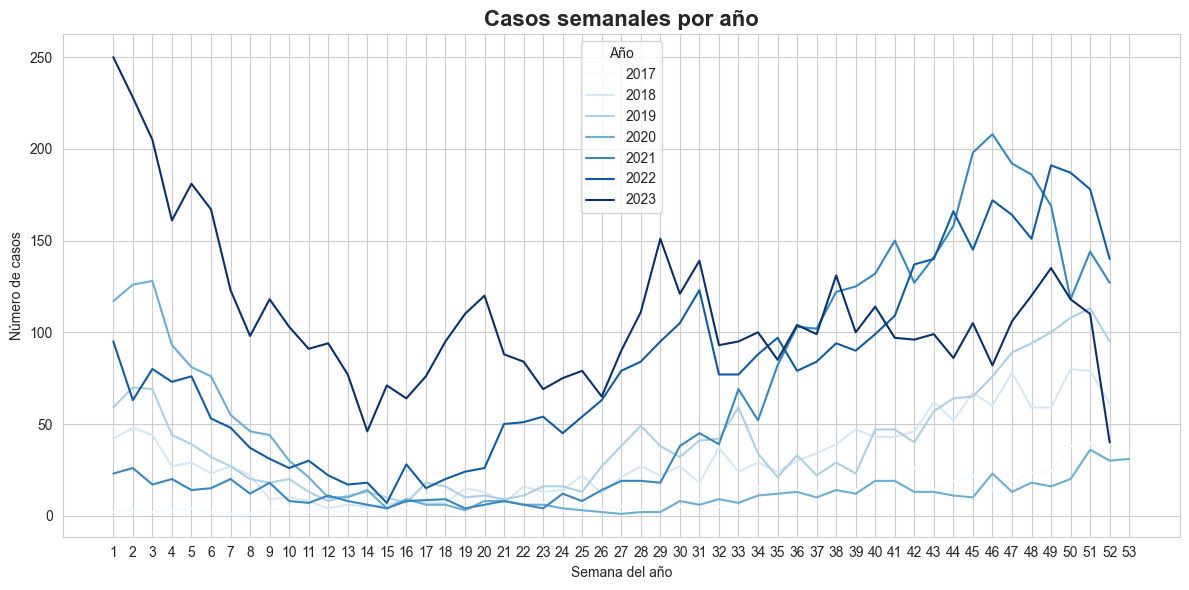

In [66]:
# Contar casos por semana y año
conteo_semanal = df.groupby(['año', 'semana']).size().reset_index(name='casos')

def graficar_casos_semanales_por_año(df_conteo, nombre_grafico="Casos semanales por año"):
    plt.figure(figsize=(12, 6))
    sns.set_style("whitegrid")

    años = sorted(df_conteo['año'].unique())
    colores = cm.get_cmap('Blues', len(años))  # paleta con N tonos

    for i, año in enumerate(años):
        datos_año = df_conteo[df_conteo['año'] == año]
        plt.plot(datos_año['semana'], datos_año['casos'], 
                label=str(año), color=colores(i))
        
    plt.title(nombre_grafico, fontsize=16, fontweight='bold')
    plt.xlabel("Semana del año")
    plt.ylabel("Número de casos")
    plt.xticks(range(1, 54))  # Semanas ISO van de 1 a 53
    plt.legend(title="Año")
    plt.tight_layout()
    plt.show()

graficar_casos_semanales_por_año(conteo_semanal)

Al detallar los registros por la semana epidemiológica, se evidencia que existe un aumento de casos hacia los últimos meses de cada año, con algunos picos hacia la mitad del año. 

En promedio, los casos se dan en su mayoría entre la semana 28 y la semana 44, con una media de distribución hacia la semana 30.

Con respecto a cada año, la mayor variabilidad se evidencia en el 2023. Los años 2021 y 2022, presentan notados picos de alza hacia finales de cada año. El 2017 y el 2020, son los años de manor variabilidad. 

## Exploración binaria

In [ ]:
demograficas = [
    "sexo",                    # M/F
    "edad_años",               # Edad numérica
    "ciclo_vital",             # Etapa de vida
    "grupo_etnico",            # Grupo étnico declarado
    "regimen_salud"            # Régimen (contributivo, subsidiado, etc.)
]

    # Variables del evento epidemiológico
evento = [
    "evento",                  # Clásico, grave
    "tipo_de_caso",               # Confirmado, probable, descartado
    "hospitalizacion",         # Sí/No
    "desenlace"                # Recuperado, fallecido, etc.
]

    # Variables de temporalidad
temporalidad = [
    "año",                     # Año del evento
    "semana",                  # Semana epidemiológica
    "periodo",                 # Periodo (cada 4 semanas)
    "fecha_inicio_sintomas",   # Inicio de síntomas
    "fecha_consulta",          # Fecha de consulta
    "fecha_hospitalizacion",   # Fecha de hospitalización
    "fecha_notificacion",      # Fecha de notificación
    "fecha_nacimiento"         # Fecha de nacimiento
]

    # Variables espaciales
espacial = [
    "municipio"                # Municipio de ocurrencia
    "area",                    # Urbana o rural
    "localidad",                # Localidad (si aplica)
    "direccion"                # Dirección (si aplica)
    "barrio"                    # Barrio (si aplica)

]

In [69]:
import pandas as pd
from scipy.stats import chi2_contingency

def prueba_independencia_chi(df, alpha=0.05):
    # 1. Seleccionar variables categóricas
    cat_vars = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    
    resultados = []

    # 2. Iterar sobre pares únicos
    for i in range(len(cat_vars)):
        for j in range(i + 1, len(cat_vars)):
            var1 = cat_vars[i]
            var2 = cat_vars[j]

            # 3. Crear tabla de contingencia
            tabla = pd.crosstab(df[var1], df[var2])

            # 4. Aplicar prueba chi-cuadrado
            chi2, p, dof, expected = chi2_contingency(tabla)

            # 5. Evaluar independencia
            if p <= alpha:  # Solo guardar si son dependientes
                resultado = {
                    'Variable 1': var1,
                    'Variable 2': var2,
                    'p-valor': round(p, 4),
                    'Independientes': 'No'
                }
                resultados.append(resultado)

    # 6. Convertir a DataFrame para revisión
    return pd.DataFrame(resultados)

df_resultados = prueba_independencia_chi(df)
print(df_resultados)


         Variable 1       Variable 2  p-valor Independientes
0              sexo      ciclo_vital   0.0000             No
1              sexo    regimen_salud   0.0000             No
2              sexo             area   0.0039             No
3              sexo        municipio   0.0488             No
4       ciclo_vital    regimen_salud   0.0000             No
5       ciclo_vital           evento   0.0003             No
6       ciclo_vital     tipo_de_caso   0.0000             No
7       ciclo_vital  hospitalizacion   0.0000             No
8       ciclo_vital        localidad   0.0023             No
9       ciclo_vital           barrio   0.0000             No
10      ciclo_vital        direccion   0.0000             No
11      ciclo_vital        municipio   0.0000             No
12     grupo_etnico    regimen_salud   0.0000             No
13     grupo_etnico     tipo_de_caso   0.0000             No
14     grupo_etnico  hospitalizacion   0.0000             No
15     grupo_etnico     